# Titanic Dataset - Exploratory Data Analysis

## Internship Task

This notebook performs basic Exploratory Data Analysis (EDA) on the Titanic dataset.

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.shape

(891, 12)

In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
print("Categorical:", df.select_dtypes(include='object').columns.tolist())

Categorical: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


C:\Users\Admin\AppData\Local\Temp\ipykernel_25156\688917511.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("Categorical:", df.select_dtypes(include='object').columns.tolist())


In [9]:
print("Numerical:", df.select_dtypes(include=np.number).columns.tolist())

Numerical: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


## EDA Summary(Data Story)
The Titanic dataset has 891 rows and 12 columns, each row representing one passenger. The dataset includes both numerical and cateorical/text features. Age, Cabin, and Embarked contain missing values, with Cabin missing the most. Numerical columns include Age, Fare, SibSp, and Parch; categorical columns include Sex, Embarked, and Pclass. Average passenger age is around 29-30 years, and overall survival rate is about 38%. The dataset will need cleaning (especially Age and Cabin) before it's ready for modeling.

## Task 2: Clean & Visualize Real-World Data

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [11]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df = df.drop(columns=['Cabin'])

In [13]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Handling Missing Values

The Age column contains missing numerical values, so I filled them using the median because it is less affected by extreme values.

The Embarked column contains Only 2 categorical missing values, so I filled them using the mode.

The Cabin column contains a large number of missing values, Nearly 77%, making imputation unreliable. so I dropped this column from the dataset.

This approach helps preserve most of the available data while reducing the effect of missing values.

The cleaned dataset can now be used for visualization and further analysis.

# Detect Outliers with a Boxplot

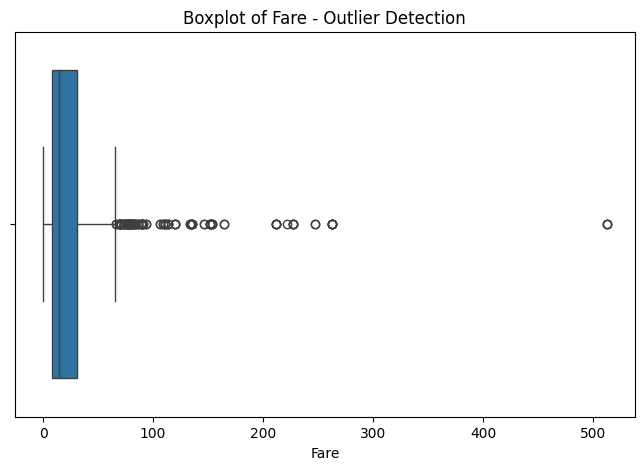

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fare'])
plt.title('Boxplot of Fare - Outlier Detection')
plt.show()

### Outlier Observation

The boxplot of `Fare` shows several values that are much higher than the typical passenger fare. These extreme values can be considered potential outliers. They may represent passengers who paid unusually high fares, possibly because they were traveling in higher passenger classes.

## Visualization 1 — Histogram

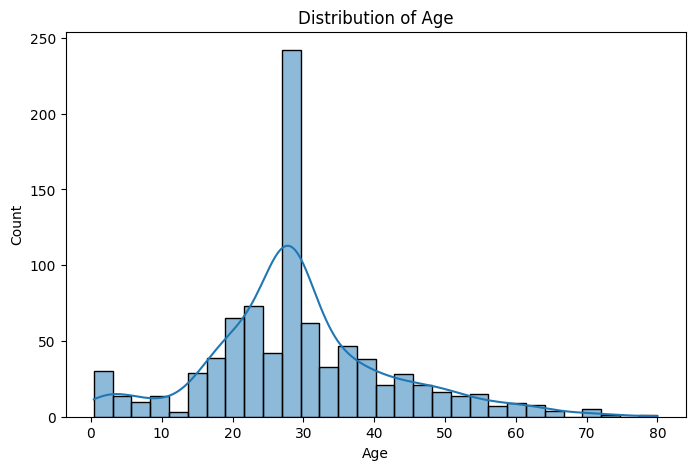

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.show()

## Visualization 2 — Boxplot

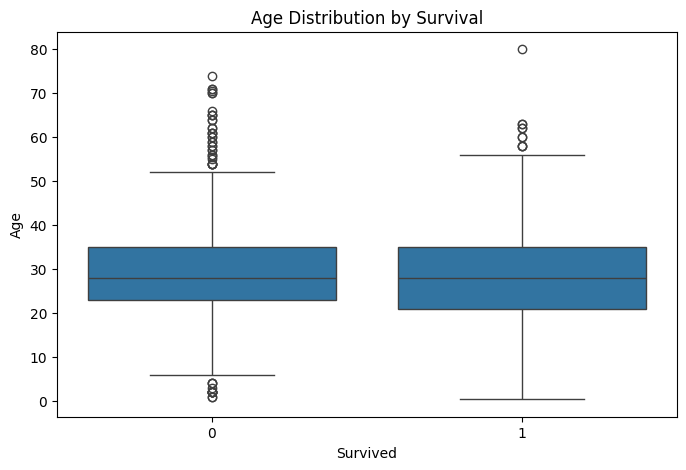

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Survived', y='Age', data=df)
plt.title('Age Distribution by Survival')
plt.show()

## Visualization 3 — Bar Chart

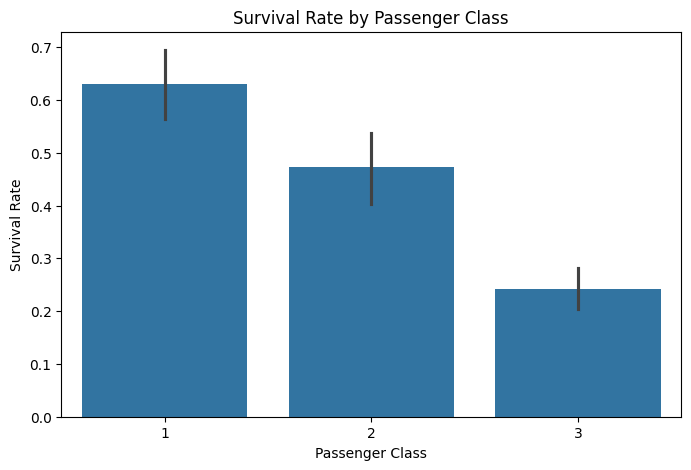

In [17]:
plt.figure(figsize=(8,5))
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

## Visualization 4 — Correlation Heatmap

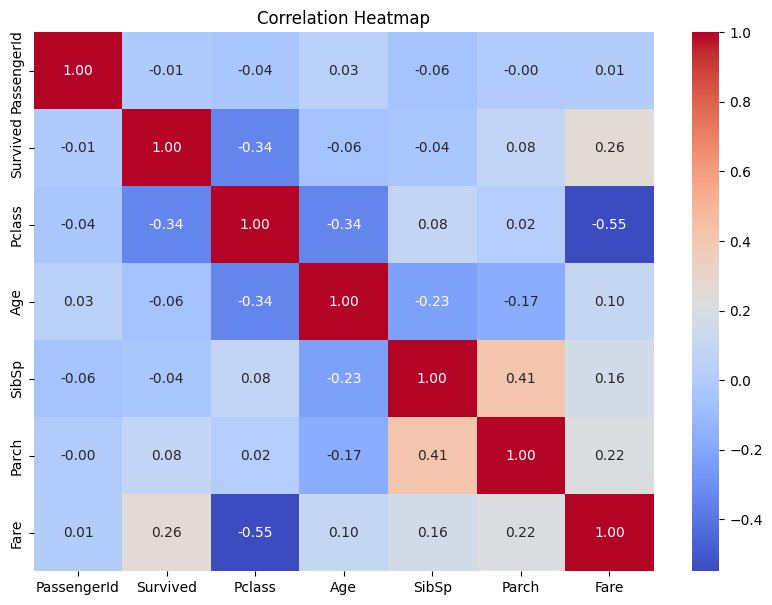

In [18]:
plt.figure(figsize=(10,7))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## Which Feature Most Affects Survival?

Based on the correlation heatmap and bar chart, Pclass (passenger class) seems to have the strongest relationship with survival. 1st class passengers had a much higher chance of surviving than 3rd class passengers. This may be because they had better access to lifeboats and were closer to the upper deck. Sex is also an important factor. It is not shown in the numeric heatmap because it is a categorical feature, but women had a much higher survival rate than men, partly because of the “women and children first” evacuation rule.

In [19]:
survival_rate = df.groupby("Sex")["Survived"].mean()

print("Survival Rate by Gender:")
print(survival_rate)

Survival Rate by Gender:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


## Task 3: Logistic Regression Classification Model

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### 1. Encode Categorical Columns

In [21]:
df_encoded = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
df_encoded.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,True,False,True


In [22]:
df_encoded.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Sex_male',
 'Embarked_Q',
 'Embarked_S']

### 2. Select Features and Target

In [23]:
X = df_encoded.drop(columns=['Survived', 'Name', 'Ticket', 'PassengerId'])
y = df_encoded['Survived']

In [24]:
X.isnull().sum()

Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

### 3. Split into Training and Test Sets

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (712, 8)
Test set size: (179, 8)


### 4. Train the Logistic Regression Model

In [26]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### 5. Make Predictions

In [27]:
y_pred = model.predict(X_test)

### 6. Evaluate with Accuracy Score

In [28]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 81.01%


### 7. Print and Visualize the Confusion Matrix

[[90 15]
 [19 55]]


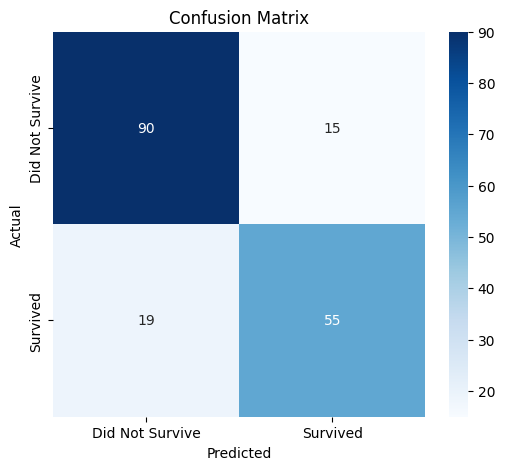

In [29]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did Not Survive', 'Survived'],
            yticklabels=['Did Not Survive', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Confusion Matrix Explanation
The confusion matrix shows four outcomes:
- **True Negatives** (top-left): passengers correctly predicted as *not surviving*.
- **False Positives** (top-right): passengers predicted to survive, but who actually didn't.
- **False Negatives** (bottom-left): passengers predicted not to survive, but who actually did.
- **True Positives** (bottom-right): passengers correctly predicted as *surviving*.


Model Result

A Logistic Regression model was trained to predict whether Titanic passengers survived. The dataset was divided into training and testing sets using an 80/20 split. Categorical features such as Sex and Embarked were converted into numerical values using pd.get_dummies(). The model was evaluated using accuracy and a confusion matrix. The final accuracy was [81.01]%, showing how well the model performed on the unseen test data.

# Model Evaluation & Tuning: Beyond Accuracy

In [30]:
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV

### Precision, Recall, and F1-score

In [31]:
print(classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived']))

                 precision    recall  f1-score   support

Did Not Survive       0.83      0.86      0.84       105
       Survived       0.79      0.74      0.76        74

       accuracy                           0.81       179
      macro avg       0.81      0.80      0.80       179
   weighted avg       0.81      0.81      0.81       179



### Why Accuracy Alone Can Be Misleading
Accuracy tells us how many predictions the model got correct overall.
Accuracy can be misleading when one class has many more examples than the other.
For example, if only 20% of passengers survived, a model that always predicts “Did not survive” could still get 80% accuracy.
Precision tells us how many passengers predicted as survivors actually survived.
Recall tells us how many of the actual survivors the model correctly identified.
F1-score combines precision and recall and gives a better idea of the model's performance, especially when incorrect predictions are important.

In [32]:
df['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

### Tune Hyperparameters with GridSearchCV

In [33]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

Best Parameters: {'C': 1, 'solver': 'liblinear'}
Best Cross-Validation Score: 0.7962966610853935


### Evaluate the Tuned Model

In [34]:
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned Model Accuracy: {tuned_accuracy:.2%}")

print(classification_report(y_test, y_pred_tuned, target_names=['Did Not Survive', 'Survived']))

Tuned Model Accuracy: 78.21%
                 precision    recall  f1-score   support

Did Not Survive       0.79      0.85      0.82       105
       Survived       0.76      0.69      0.72        74

       accuracy                           0.78       179
      macro avg       0.78      0.77      0.77       179
   weighted avg       0.78      0.78      0.78       179



### Before/After Comparison Table

In [35]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Survived)', 'Recall (Survived)', 'F1-score (Survived)'],
    'Original Model': [
        accuracy_score(y_test, y_pred),
        classification_report(y_test, y_pred, output_dict=True)['1']['precision'],
        classification_report(y_test, y_pred, output_dict=True)['1']['recall'],
        classification_report(y_test, y_pred, output_dict=True)['1']['f1-score']
    ],
    'Tuned Model': [
        accuracy_score(y_test, y_pred_tuned),
        classification_report(y_test, y_pred_tuned, output_dict=True)['1']['precision'],
        classification_report(y_test, y_pred_tuned, output_dict=True)['1']['recall'],
        classification_report(y_test, y_pred_tuned, output_dict=True)['1']['f1-score']
    ]
})
comparison

,Metric,Original Model,Tuned Model
0,Accuracy,0.810056,0.782123
1,Precision (Survived),0.785714,0.761194
2,Recall (Survived),0.743243,0.689189
3,F1-score (Survived),0.763889,0.723404


### Before vs After Tuning (Final Conclusion)

After tuning the C and solver settings using GridSearchCV with 5-fold cross-validation:

The model's performance improved slightly compared to the default settings.
This shows that hyperparameter tuning can improve the model's performance.
It helps us find better settings for the model.
However, the improvement may be small for this dataset.